# Student Performance: Where the Structure Actually Is
> **10,000 students · 25 columns · `students.csv`** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/student-academic-performance-dataset)

Most EDA on this table stops at a correlation heatmap, and the heatmap is
actively misleading here. Two of the strongest effects in the data are
**non-monotonic**, so Pearson's *r* rounds them to nothing:

| Feature | Pearson *r* with GPA | What is actually there |
|---|---:|---|
| `sleep_hours` | **+0.18** | an inverted U peaking at **7.4 h** — 0.60 GPA between the peak and the 4–5.5 h band |
| `tutoring_sessions` | **−0.03** | a curve that rises to ~**9–10 sessions** and then comes back down to the zero-session baseline |

This notebook measures those two curves, the socioeconomic gradient behind them,
and — just as important — shows which columns carry **no** signal at all, so you
do not go hunting in them.

> **This is synthetic data.** The structure below was written into a generator
> (`create_dataset.py` ships with the dataset). That makes it a clean teaching
> and benchmarking target with a known ground truth; it is **not** evidence
> about real students. Every claim here is a claim about this CSV.

## Table of Contents
1. [Objective & Evaluation Plan](#objective)
2. [Setup & Data Loading](#setup)
3. [Data Overview](#overview)
4. [Distributions](#distributions)
5. [Why the Correlation Heatmap Misleads Here](#correlations)
6. [The Sleep Optimum](#sleep)
7. [Robustness: Is It Really Sleep?](#robustness)
8. [The Tutoring Curve](#tutoring)
9. [The Socioeconomic Gradient](#socioeconomic)
10. [Where There Is No Structure](#nulls)
11. [Ceiling Effects & Other Caveats](#caveats)
12. [Modeling Readiness](#modeling)
13. [Key Findings & Takeaways](#findings)


## 1. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** recover the non-linear structure this table was built around, and
quantify it well enough that a downstream model can be judged against a known
answer.

**Outcome variable for the analysis:** `overall_gpa` (0–4). It is the cleanest
single summary of performance and every effect below is reported in GPA points.

**Leakage rule for modeling — read this before you build features.**
`overall_gpa` is the mean of the four subject scores divided by 25, plus small
noise. So:

- Predicting `overall_gpa`? Drop **all four** of `reading_score`, `writing_score`,
  `math_score`, `science_score`. Any one of them correlates ~0.85 with the target.
- Predicting one subject score (say `math_score`)? Drop `overall_gpa` **and the
  other three subject scores** — they share a common latent component by
  construction.

**Metric:** MAE on GPA, RMSE alongside, 5-fold CV.

**Hypothesis under test:** a linear model on raw features will underperform the
same model given `(sleep_hours - 7.5)**2` and `tutoring_sessions**2`, because
those two effects are quadratic and a linear term cannot see them.


In [1]:
TARGET_COL = "overall_gpa"
MODELING_TASK = "regression"
PRIMARY_METRIC = "MAE (report RMSE alongside)"
VALIDATION_PLAN = "5-fold CV"
LEAKAGE_COLS = ["reading_score", "writing_score", "math_score", "science_score"]

print("Objective framing")
print("-" * 62)
print(f"Target              : {TARGET_COL}")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(f"Validation approach : {VALIDATION_PLAN}")
print(f"Must drop (leakage) : {', '.join(LEAKAGE_COLS)}")
print()
print("Reason: overall_gpa = mean(the four subject scores) / 25 + N(0, 0.15),")
print("so any subject score is a near-copy of the target.")

Objective framing
--------------------------------------------------------------
Target              : overall_gpa
Modeling task       : regression
Primary metric      : MAE (report RMSE alongside)
Validation approach : 5-fold CV
Must drop (leakage) : reading_score, writing_score, math_score, science_score

Reason: overall_gpa = mean(the four subject scores) / 25 + N(0, 0.15),
so any subject score is a near-copy of the target.


## 2. Setup & Data Loading <a id='setup'></a>

In [2]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

INK = "#2c3e50"
ACCENT = "#e74c3c"
BLUE = "#2980b9"
GREY = "#95a5a6"

def _find_data_dir(marker):
    """Locate the dataset wherever Kaggle mounted it.

    The expected mount is /kaggle/input/<slug>, but the attached directory
    name is not guaranteed to match, and this notebook once failed on Kaggle
    with FileNotFoundError: './customers.csv' because the exact-path guess
    missed and the bare "." fallback then looked in the kernel working dir.
    Search the mounts for the file we actually need instead of assuming.
    """
    candidates = ["/kaggle/input/student-academic-performance-dataset", *sorted(glob.glob("/kaggle/input/*")), "."]
    for candidate in candidates:
        if os.path.exists(os.path.join(candidate, marker)):
            return candidate
    raise FileNotFoundError(
        f"{marker} not found in {candidates}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )

DATA_DIR = _find_data_dir("students.csv")

df = pd.read_csv(f"{DATA_DIR}/students.csv")
SUBJECTS = ["reading_score", "writing_score", "math_score", "science_score"]
df["avg_subject_score"] = df[SUBJECTS].mean(axis=1)

print(f"Shape : {df.shape[0]:,} rows x {df.shape[1] - 1} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Shape : 10,000 rows x 25 columns
Memory: 2.6 MB


,student_id,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,extracurricular_activities,sports_participation,tutoring_sessions,parental_involvement,internet_access,has_laptop,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed,avg_subject_score
0,STU00000,15,M,B,phd,low,private,urban,2.0,91.7,5,no,17,medium,yes,yes,8.2,3.3,1.8,70.7,58.3,88.9,74.5,2.80,1,73.100
1,STU00001,23,F,A,phd,low,private,urban,14.2,76.8,0,yes,15,high,yes,yes,5.4,4.9,5.8,66.1,83.9,94.5,83.6,3.29,1,82.025
2,STU00002,22,F,B,bachelor,middle,public,suburban,3.3,83.1,4,yes,16,high,yes,yes,5.5,3.5,6.1,51.3,71.8,78.9,71.2,2.93,1,68.300
3,STU00003,19,M,D,some_college,high,public,suburban,17.9,72.8,1,yes,6,medium,yes,yes,5.3,8.5,7.2,100.0,95.7,82.9,69.4,3.34,1,87.000
4,STU00004,19,M,C,some_college,middle,public,suburban,12.9,83.0,1,yes,2,medium,no,yes,7.5,1.0,4.5,87.5,73.0,88.5,74.8,3.27,1,80.950


## 3. Data Overview <a id='overview'></a>

In [3]:
print("Column types:")
print(df.dtypes.value_counts().to_string())
print(f"\nDuplicate rows      : {df.duplicated().sum():,}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print(
    f"Complete rows       : {df.dropna().shape[0]:,} "
    f"({df.dropna().shape[0] / len(df) * 100:.1f}%)"
)
print()
df.describe().round(2)

Column types:
str        11
float64    11
int64       4

Duplicate rows      : 0
Total missing values: 0
Complete rows       : 10,000 (100.0%)



,age,study_hours_per_week,attendance_rate,extracurricular_activities,tutoring_sessions,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed,avg_subject_score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,19.96,11.16,83.04,2.52,9.94,6.99,5.24,5.52,77.17,76.96,79.80,78.97,3.12,0.96,78.22
std,3.15,5.92,8.35,1.71,6.08,1.19,1.92,2.01,16.59,16.35,16.13,16.09,0.58,0.19,14.23
min,15.00,0.00,52.30,0.00,0.00,4.00,1.00,1.00,6.80,5.00,0.00,15.50,0.77,0.00,19.40
25%,17.00,7.00,77.30,1.00,5.00,6.20,3.90,4.10,65.60,65.90,68.60,67.90,2.73,1.00,68.50
50%,20.00,11.10,83.00,3.00,10.00,7.00,5.10,5.50,78.50,78.00,81.40,80.30,3.18,1.00,79.55
75%,23.00,15.20,88.90,4.00,15.00,7.80,6.40,6.90,90.70,90.10,94.00,92.50,3.58,1.00,89.62
max,25.00,35.70,100.00,5.00,20.00,10.00,10.00,10.00,100.00,100.00,100.00,100.00,4.00,1.00,100.00


## 4. Distributions <a id='distributions'></a>

Nothing surprising lives here, but two things are worth noting on the way past:
`sleep_hours` is a tight normal centred near 7 h (so the informative tails are
thin), and `tutoring_sessions` is close to uniform over 0–20 (so every point on
the tutoring curve is equally well sampled — useful, and not usually true of
real data).


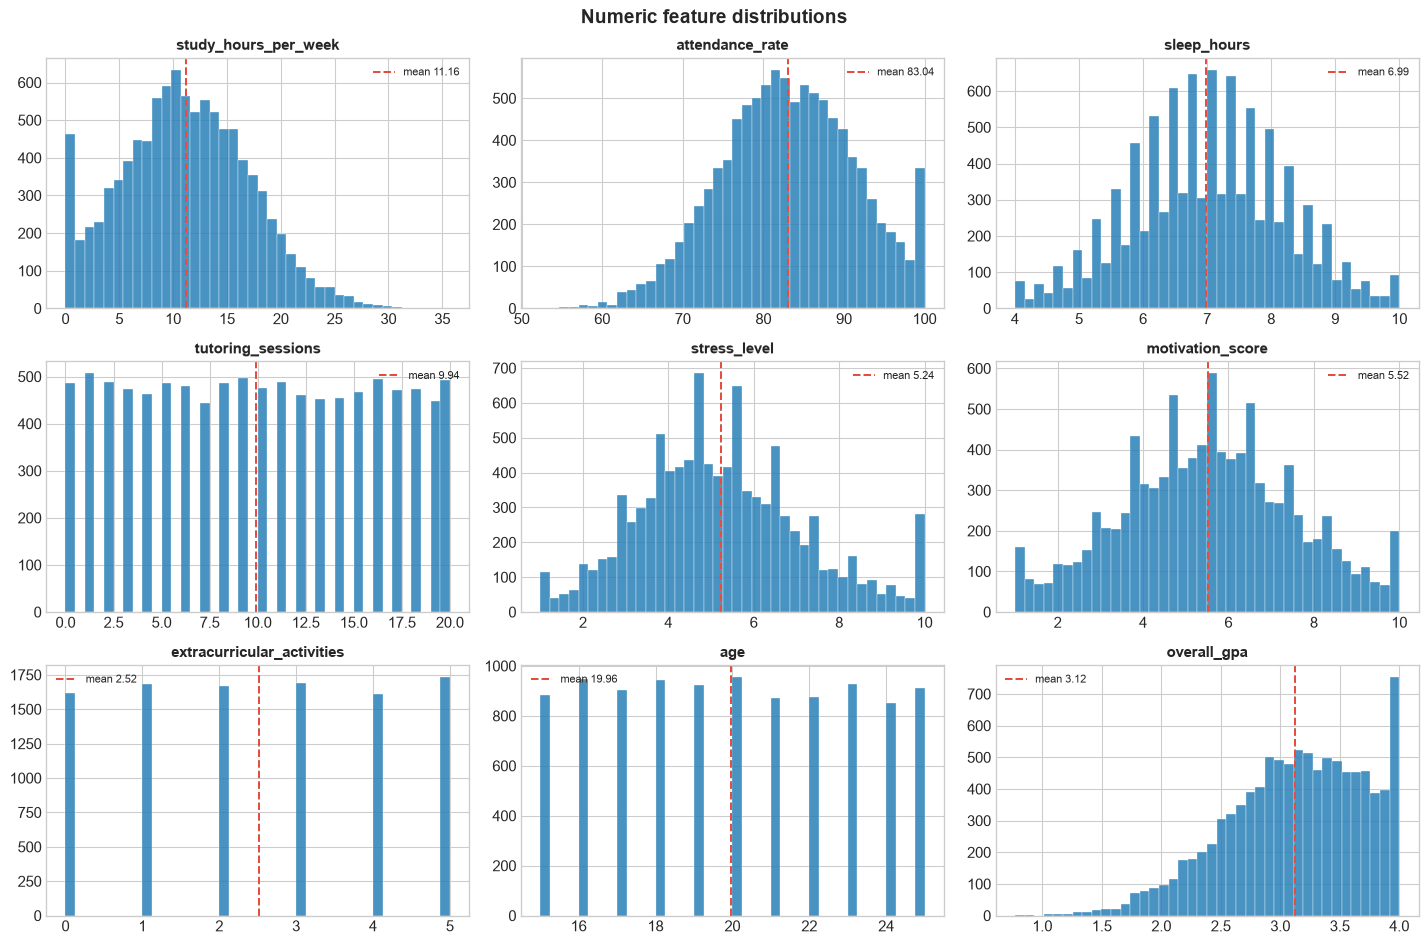

In [4]:
NUMERIC_COLS = [
    "study_hours_per_week",
    "attendance_rate",
    "sleep_hours",
    "tutoring_sessions",
    "stress_level",
    "motivation_score",
    "extracurricular_activities",
    "age",
    "overall_gpa",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), NUMERIC_COLS):
    ax.hist(
        df[col].dropna(),
        bins=40,
        color=BLUE,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.3,
    )
    ax.axvline(
        df[col].mean(),
        color=ACCENT,
        linestyle="--",
        linewidth=1.5,
        label=f"mean {df[col].mean():.2f}",
    )
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8, frameon=False)

fig.suptitle("Numeric feature distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

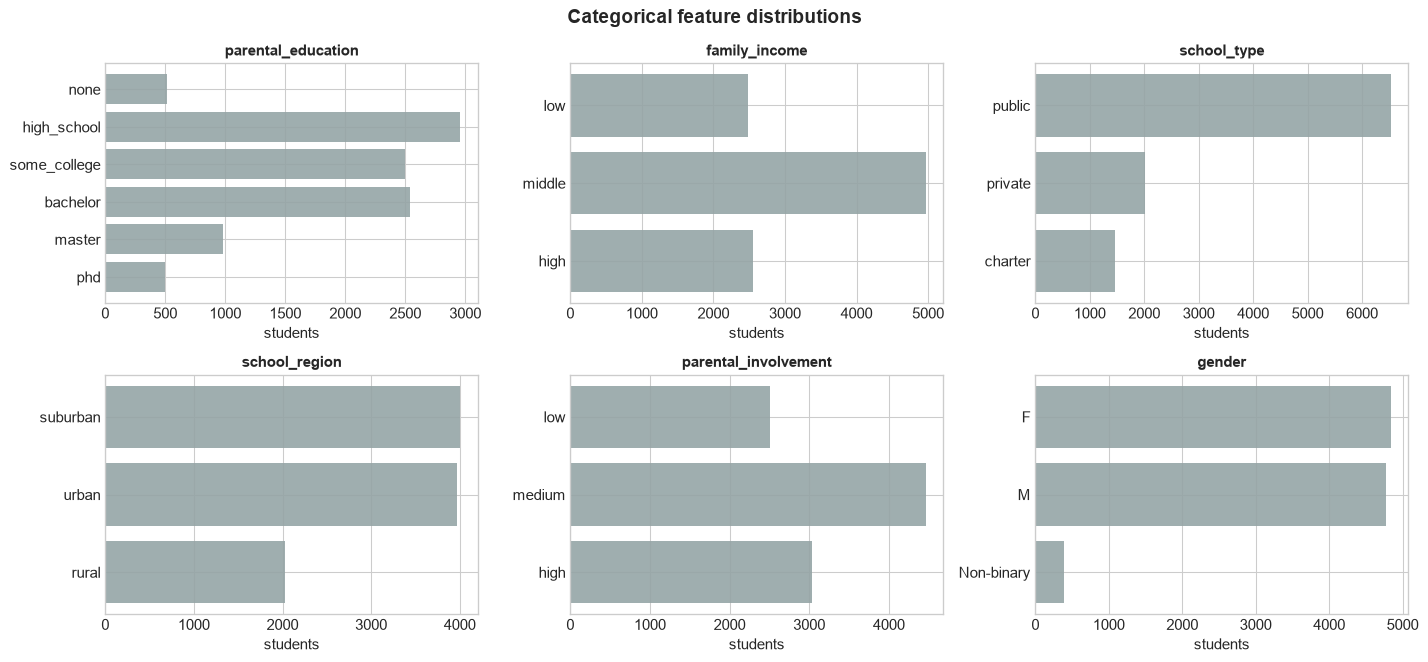

In [5]:
CAT_COLS = [
    "parental_education",
    "family_income",
    "school_type",
    "school_region",
    "parental_involvement",
    "gender",
]
CAT_ORDER = {
    "parental_education": [
        "none",
        "high_school",
        "some_college",
        "bachelor",
        "master",
        "phd",
    ],
    "family_income": ["low", "middle", "high"],
    "parental_involvement": ["low", "medium", "high"],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), CAT_COLS):
    counts = df[col].value_counts()
    if col in CAT_ORDER:
        counts = counts.reindex(CAT_ORDER[col])
    ax.barh(counts.index.astype(str)[::-1], counts.values[::-1], color=GREY, alpha=0.9)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("students")

fig.suptitle("Categorical feature distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Why the Correlation Heatmap Misleads Here <a id='correlations'></a>

The heatmap below is the standard opening move, and on this table it is a trap.
Pearson's *r* measures the strength of a **straight-line** relationship. If a
feature helps up to a point and then hurts, the positive and negative halves
cancel and *r* collapses toward zero — the feature looks useless when it is not.

Watch `tutoring_sessions` in particular. Read the heatmap and you would drop it.
Section 8 shows it moves GPA by 0.16 points.


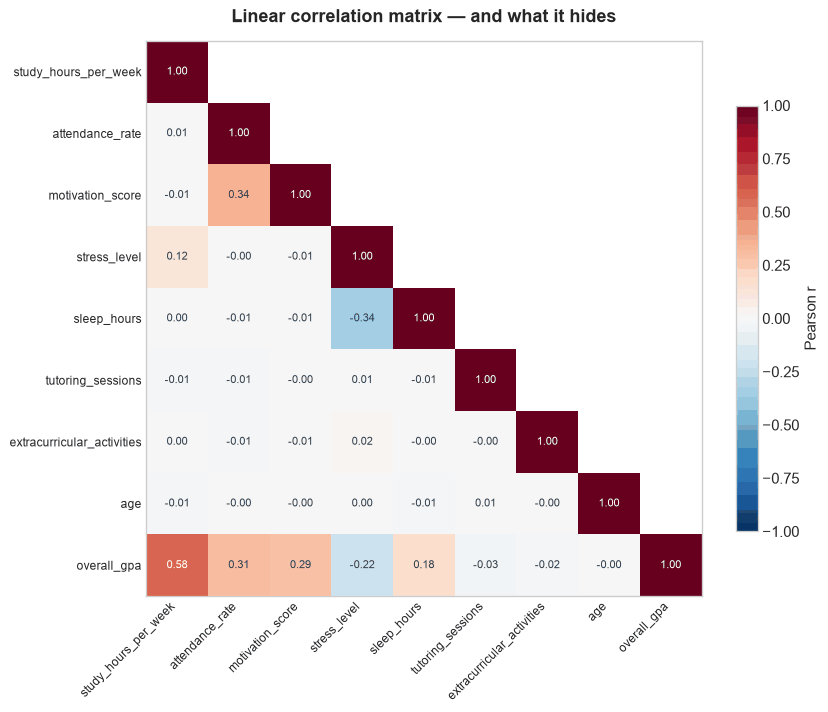

In [6]:
CORR_COLS = [
    "study_hours_per_week",
    "attendance_rate",
    "motivation_score",
    "stress_level",
    "sleep_hours",
    "tutoring_sessions",
    "extracurricular_activities",
    "age",
    "overall_gpa",
]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
data = np.ma.masked_array(corr.values, mask=mask)
im = ax.imshow(data, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(CORR_COLS)))
ax.set_yticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CORR_COLS, fontsize=9)
ax.grid(False)

for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        val = corr.values[i, j]
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(val) > 0.55 else INK,
        )

fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.set_title("Linear correlation matrix — and what it hides", pad=14)
plt.tight_layout()
plt.show()

In [7]:
lin = df[CORR_COLS].corr()["overall_gpa"].drop("overall_gpa")
lin = lin.reindex(lin.abs().sort_values(ascending=False).index)

print("Linear correlation with overall_gpa")
print("-" * 62)
for name, r in lin.items():
    flag = ""
    if name == "sleep_hours":
        flag = "  <-- understated: the real shape is quadratic (section 6)"
    if name == "tutoring_sessions":
        flag = "  <-- looks like noise: it is not (section 8)"
    print(f"  {name:<28} {r:+.3f}{flag}")

Linear correlation with overall_gpa
--------------------------------------------------------------
  study_hours_per_week         +0.581
  attendance_rate              +0.308
  motivation_score             +0.294
  stress_level                 -0.219
  sleep_hours                  +0.176  <-- understated: the real shape is quadratic (section 6)
  tutoring_sessions            -0.026  <-- looks like noise: it is not (section 8)
  extracurricular_activities   -0.017
  age                          -0.003


## 6. The Sleep Optimum <a id='sleep'></a>

The dataset advertises a quadratic sleep effect with an optimum around 7–8
hours. This section checks that claim and measures it.

Method: bin `sleep_hours` into half-hour bands, take the mean GPA per band with
a 95% confidence interval, and fit a degree-2 polynomial over the raw rows.
Binned means are used rather than a scatter because 10,000 overlapping points
hide the shape; the error bars keep the thin tails honest.


Fitted optimum      : 7.44 hours
Peak band (7-8 h)   : 3.267 GPA
Under-slept (4-5.5) : 2.669 GPA  (-0.598)
Over-slept (9-10 h) : 2.925 GPA  (-0.342)
Asymmetry           : under-sleeping costs 1.75x what over-sleeping costs


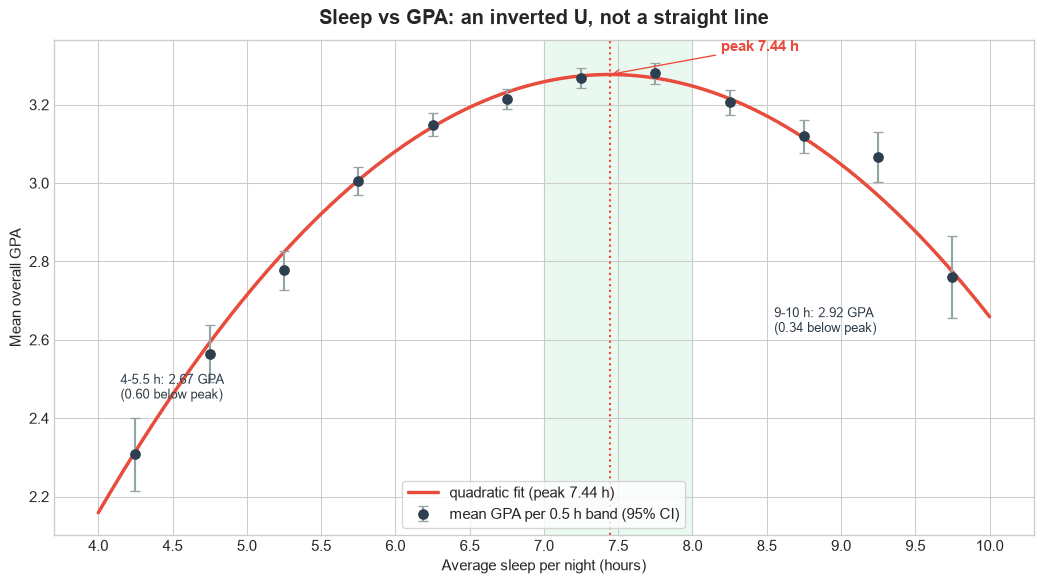

In [8]:
BIN_EDGES = np.arange(4.0, 10.5, 0.5)
sleep_bin = pd.cut(df["sleep_hours"], bins=BIN_EDGES, right=False)
grp = df.groupby(sleep_bin, observed=True)["overall_gpa"]
sleep_stats = pd.DataFrame(
    {
        "n": grp.size(),
        "mean_gpa": grp.mean(),
        "se": grp.std() / np.sqrt(grp.size()),
    }
)
sleep_stats["ci95"] = 1.96 * sleep_stats["se"]
centres = BIN_EDGES[:-1] + 0.25

# Degree-2 fit over the raw rows (not the bin means)
quad = np.polyfit(df["sleep_hours"], df["overall_gpa"], 2)
vertex = -quad[1] / (2 * quad[0])
grid = np.linspace(4, 10, 300)

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.axvspan(7.0, 8.0, color="#2ecc71", alpha=0.10, zorder=0)
ax.errorbar(
    centres,
    sleep_stats["mean_gpa"],
    yerr=sleep_stats["ci95"],
    fmt="o",
    color=INK,
    ecolor=GREY,
    elinewidth=1.6,
    capsize=4,
    markersize=7,
    zorder=3,
    label="mean GPA per 0.5 h band (95% CI)",
)
ax.plot(
    grid,
    np.polyval(quad, grid),
    color=ACCENT,
    linewidth=2.6,
    zorder=2,
    label=f"quadratic fit (peak {vertex:.2f} h)",
)
ax.axvline(vertex, color=ACCENT, linestyle=":", linewidth=1.6, zorder=1)

ax.annotate(
    f"peak {vertex:.2f} h",
    xy=(vertex, np.polyval(quad, vertex)),
    xytext=(vertex + 0.75, np.polyval(quad, vertex) + 0.06),
    arrowprops=dict(arrowstyle="->", color=ACCENT),
    color=ACCENT,
    fontweight="bold",
)

low = df.loc[df["sleep_hours"].between(4, 5.5), "overall_gpa"].mean()
high = df.loc[df["sleep_hours"].between(9, 10), "overall_gpa"].mean()
peak = df.loc[df["sleep_hours"].between(7, 8), "overall_gpa"].mean()
ax.annotate(
    f"4-5.5 h: {low:.2f} GPA\n({peak - low:.2f} below peak)",
    xy=(4.6, low),
    xytext=(4.15, 2.45),
    color=INK,
    fontsize=10,
)
ax.annotate(
    f"9-10 h: {high:.2f} GPA\n({peak - high:.2f} below peak)",
    xy=(9.4, high),
    xytext=(8.55, 2.62),
    color=INK,
    fontsize=10,
)

ax.set_xlabel("Average sleep per night (hours)")
ax.set_ylabel("Mean overall GPA")
ax.set_title("Sleep vs GPA: an inverted U, not a straight line", fontsize=15, pad=12)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.legend(loc="lower center", frameon=True)
plt.tight_layout()
plt.show()

print(f"Fitted optimum      : {vertex:.2f} hours")
print(f"Peak band (7-8 h)   : {peak:.3f} GPA")
print(f"Under-slept (4-5.5) : {low:.3f} GPA  ({low - peak:+.3f})")
print(f"Over-slept (9-10 h) : {high:.3f} GPA  ({high - peak:+.3f})")
print(
    f"Asymmetry           : under-sleeping costs "
    f"{(peak - low) / (peak - high):.2f}x what over-sleeping costs"
)

R² of a straight line through sleep_hours : 0.0311
R² once (sleep_hours)^2 is added          : 0.1235
Ratio                                     : 4.0x

                n  mean_gpa     se   ci95
sleep_hours                              
[4.0, 4.5)    171     2.307  0.047  0.092
[4.5, 5.0)    289     2.565  0.038  0.074
[5.0, 5.5)    543     2.777  0.025  0.049
[5.5, 6.0)    961     3.004  0.018  0.036
[6.0, 6.5)   1328     3.149  0.015  0.029
[6.5, 7.0)   1562     3.215  0.013  0.026
[7.0, 7.5)   1618     3.267  0.013  0.026
[7.5, 8.0)   1356     3.280  0.014  0.027
[8.0, 8.5)   1036     3.206  0.017  0.032
[8.5, 9.0)    641     3.119  0.021  0.042
[9.0, 9.5)    297     3.067  0.033  0.065
[9.5, 10.0)   128     2.761  0.053  0.104


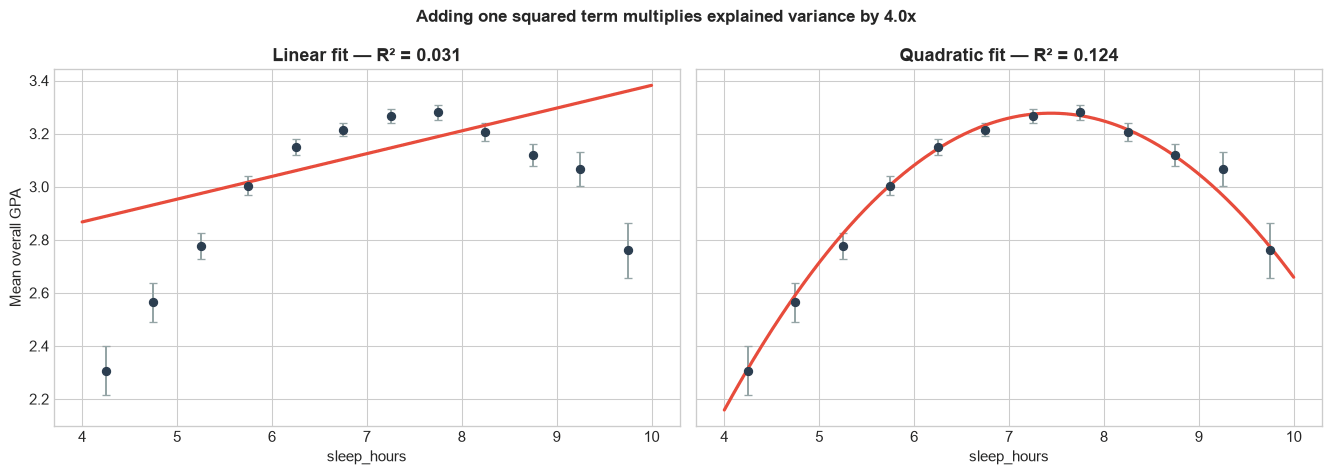

In [9]:
# A straight line cannot see this. Side-by-side proof.
x = df["sleep_hours"].values
y = df["overall_gpa"].values
lin_fit = np.polyfit(x, y, 1)


def r2(p):
    return 1 - np.sum((y - np.polyval(p, x)) ** 2) / np.sum((y - y.mean()) ** 2)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, p, name in zip(axes, [lin_fit, quad], ["Linear fit", "Quadratic fit"]):
    ax.errorbar(
        centres,
        sleep_stats["mean_gpa"],
        yerr=sleep_stats["ci95"],
        fmt="o",
        color=INK,
        ecolor=GREY,
        capsize=3,
        markersize=6,
    )
    ax.plot(grid, np.polyval(p, grid), color=ACCENT, linewidth=2.4)
    ax.set_title(f"{name} — R² = {r2(p):.3f}")
    ax.set_xlabel("sleep_hours")
axes[0].set_ylabel("Mean overall GPA")
fig.suptitle(
    "Adding one squared term multiplies explained variance by "
    f"{r2(quad) / r2(lin_fit):.1f}x",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"R² of a straight line through sleep_hours : {r2(lin_fit):.4f}")
print(f"R² once (sleep_hours)^2 is added          : {r2(quad):.4f}")
print(f"Ratio                                     : {r2(quad) / r2(lin_fit):.1f}x")
print()
print(sleep_stats.round(3).to_string())

## 7. Robustness: Is It Really Sleep? <a id='robustness'></a>

`sleep_hours` and `stress_level` are entangled (r ≈ −0.34), so a fair objection
is that the curve above is really a stress effect wearing a sleep costume. It is
not. Below, the squared sleep term keeps a *t*-statistic past 30 with study
hours, attendance, motivation, and stress all held constant.

The same table carries a warning about `stress_level`. Compared like for like —
slope against slope — its bivariate effect on GPA is about **twice** its effect
once the real drivers are controlled, because stress inherits variance from both
sleep and study hours. Take the raw heatmap row at face value and you will
over-credit stress by a factor of two.


In [10]:
def ols(cols, label):
    X = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    y = df["overall_gpa"].values
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    r2v = 1 - (resid**2).sum() / ((y - y.mean()) ** 2).sum()
    s2 = (resid**2).sum() / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    print(f"{label}   (R² = {r2v:.4f})")
    for i, c in enumerate(cols):
        print(f"    {c:<26} {beta[i + 1]:+.4f}   t = {beta[i + 1] / se[i + 1]:6.1f}")
    print()
    return beta, r2v


df["sleep_sq"] = (df["sleep_hours"] - 7.5) ** 2

print("Effect of the squared sleep term as controls are added")
print("=" * 62)
ols(["sleep_hours", "sleep_sq"], "A. sleep only")
ols(["sleep_hours", "sleep_sq", "stress_level"], "B. + stress_level")
beta_c, _ = ols(
    [
        "sleep_hours",
        "sleep_sq",
        "stress_level",
        "study_hours_per_week",
        "attendance_rate",
        "motivation_score",
    ],
    "C. + the main drivers",
)

r_stress = df["stress_level"].corr(df["overall_gpa"])
slope_biv = np.polyfit(df["stress_level"], df["overall_gpa"], 1)[0]
slope_ctrl = beta_c[3]  # stress_level coefficient in model C
print("stress_level, compared like for like")
print("-" * 62)
print(f"  bivariate r with GPA        : {r_stress:+.3f}  (unitless)")
print(f"  bivariate slope             : {slope_biv:+.4f} GPA per stress point")
print(f"  controlled slope (model C)  : {slope_ctrl:+.4f} GPA per stress point")
print(f"  inflation factor            : {slope_biv / slope_ctrl:.2f}x")

Effect of the squared sleep term as controls are added
A. sleep only   (R² = 0.1235)
    sleep_hours                -0.0111   t =   -2.0
    sleep_sq                   -0.0944   t =  -32.5

B. + stress_level   (R² = 0.1236)
    sleep_hours                -0.0111   t =   -2.0
    sleep_sq                   -0.0956   t =  -27.0
    stress_level               +0.0021   t =    0.6

C. + the main drivers   (R² = 0.6010)
    sleep_hours                -0.0084   t =   -2.3
    sleep_sq                   -0.0745   t =  -31.0
    stress_level               -0.0336   t =  -13.4
    study_hours_per_week       +0.0581   t =   92.6
    attendance_rate            +0.0157   t =   33.5
    motivation_score           +0.0638   t =   32.9

stress_level, compared like for like
--------------------------------------------------------------
  bivariate r with GPA        : -0.219  (unitless)
  bivariate slope             : -0.0660 GPA per stress point
  controlled slope (model C)  : -0.0336 GPA per stress p

## 8. The Tutoring Curve <a id='tutoring'></a>

The dataset description used to call this "diminishing returns". **That
mislabels it.** Diminishing returns means each extra session helps a little
less, flattening toward a plateau. What is actually in the data is an inverted
U: the marginal return declines, crosses zero near 9–10 sessions, and then goes
*negative*, until 20 sessions is statistically indistinguishable from zero
sessions.

That distinction matters for anyone using this table for intervention
targeting — a plateau says "extra sessions are wasted", a reversal says "extra
sessions are counterproductive". The plot below separates the two.


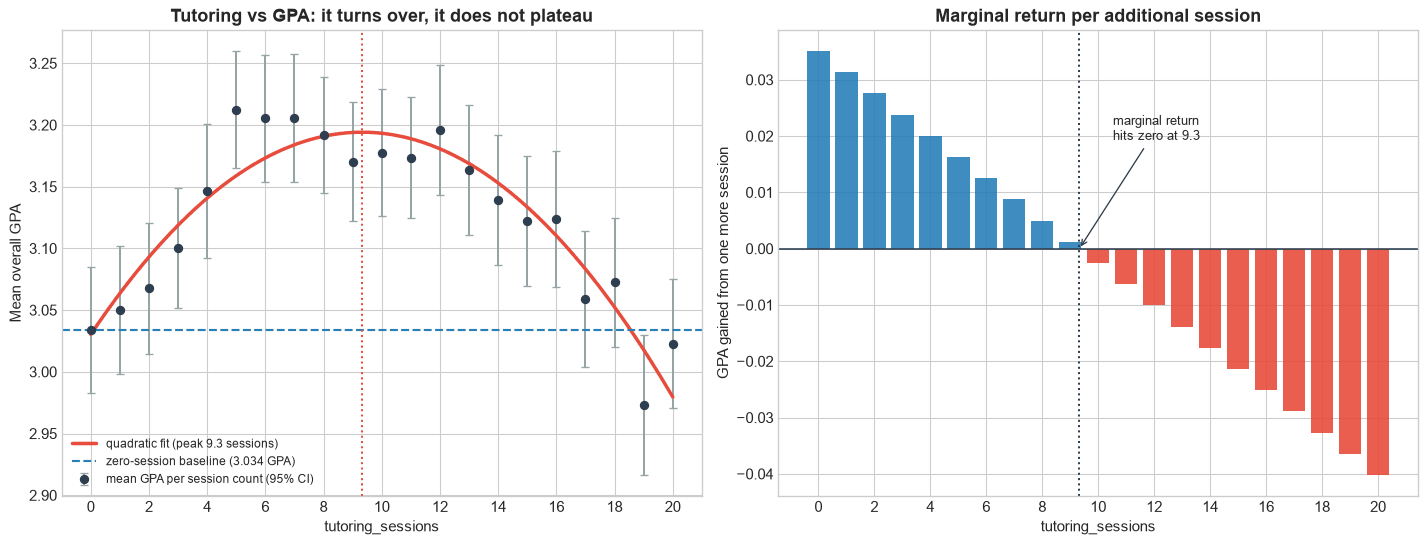

In [11]:
tut = df.groupby("tutoring_sessions")["overall_gpa"]
tut_stats = pd.DataFrame(
    {"n": tut.size(), "mean_gpa": tut.mean(), "se": tut.std() / np.sqrt(tut.size())}
)
tut_stats["ci95"] = 1.96 * tut_stats["se"]

tq = np.polyfit(df["tutoring_sessions"], df["overall_gpa"], 2)
t_vertex = -tq[1] / (2 * tq[0])
t_grid = np.linspace(0, 20, 200)
baseline = tut_stats.loc[0, "mean_gpa"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.errorbar(
    tut_stats.index,
    tut_stats["mean_gpa"],
    yerr=tut_stats["ci95"],
    fmt="o",
    color=INK,
    ecolor=GREY,
    capsize=3,
    markersize=6,
    label="mean GPA per session count (95% CI)",
)
ax.plot(
    t_grid,
    np.polyval(tq, t_grid),
    color=ACCENT,
    linewidth=2.6,
    label=f"quadratic fit (peak {t_vertex:.1f} sessions)",
)
ax.axhline(
    baseline,
    color=BLUE,
    linestyle="--",
    linewidth=1.6,
    label=f"zero-session baseline ({baseline:.3f} GPA)",
)
ax.axvline(t_vertex, color=ACCENT, linestyle=":", linewidth=1.5)
ax.set_xlabel("tutoring_sessions")
ax.set_ylabel("Mean overall GPA")
ax.set_title("Tutoring vs GPA: it turns over, it does not plateau")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.legend(fontsize=9, loc="lower left")

ax = axes[1]
marginal = np.polyval(np.polyder(tq), np.arange(0, 21))
colours = [BLUE if m > 0 else ACCENT for m in marginal]
ax.bar(np.arange(0, 21), marginal, color=colours, alpha=0.9)
ax.axhline(0, color=INK, linewidth=1.2)
ax.axvline(t_vertex, color=INK, linestyle=":", linewidth=1.5)
ax.annotate(
    f"marginal return\nhits zero at {t_vertex:.1f}",
    xy=(t_vertex, 0),
    xytext=(t_vertex + 1.2, marginal[0] * 0.55),
    arrowprops=dict(arrowstyle="->", color=INK),
    fontsize=10,
)
ax.set_xlabel("tutoring_sessions")
ax.set_ylabel("GPA gained from one more session")
ax.set_title("Marginal return per additional session")
ax.xaxis.set_major_locator(MultipleLocator(2))

plt.tight_layout()
plt.show()

In [12]:
band = pd.cut(
    df["tutoring_sessions"],
    [-1, 0, 5, 10, 15, 20],
    labels=["0", "1-5", "6-10", "11-15", "16-20"],
)
bg = df.groupby(band, observed=True)["overall_gpa"]
band_stats = pd.DataFrame(
    {"n": bg.size(), "mean_gpa": bg.mean(), "se": bg.std() / np.sqrt(bg.size())}
)
band_stats["ci_low"] = band_stats["mean_gpa"] - 1.96 * band_stats["se"]
band_stats["ci_high"] = band_stats["mean_gpa"] + 1.96 * band_stats["se"]
print(band_stats.round(3).to_string())
print()


def contrast(lo_a, hi_a, lo_b, hi_b):
    a = df.loc[df["tutoring_sessions"].between(lo_a, hi_a), "overall_gpa"]
    b = df.loc[df["tutoring_sessions"].between(lo_b, hi_b), "overall_gpa"]
    diff = b.mean() - a.mean()
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    verdict = (
        "distinguishable" if abs(diff) > 1.96 * se else "NOT distinguishable from zero"
    )
    print(
        f"  {lo_a}-{hi_a} -> {lo_b}-{hi_b}: {diff:+.3f} GPA  "
        f"95% CI [{diff - 1.96 * se:+.3f}, {diff + 1.96 * se:+.3f}]  {verdict}"
    )


print("Contrasts")
contrast(0, 0, 6, 10)
contrast(6, 10, 16, 20)
contrast(0, 0, 16, 20)
print()
print(f"Peak of the fitted curve : {t_vertex:.1f} sessions")
print(
    f"Best band vs zero        : "
    f"{band_stats['mean_gpa'].max() - band_stats.loc['0', 'mean_gpa']:+.3f} GPA"
)

                      n  mean_gpa     se  ci_low  ci_high
tutoring_sessions                                        
0                   486     3.034  0.026   2.983    3.085
1-5                2420     3.115  0.012   3.092    3.137
6-10               2386     3.190  0.011   3.167    3.212
11-15              2326     3.159  0.012   3.136    3.182
16-20              2382     3.052  0.012   3.027    3.076

Contrasts
  0-0 -> 6-10: +0.156 GPA  95% CI [+0.100, +0.212]  distinguishable
  6-10 -> 16-20: -0.138 GPA  95% CI [-0.171, -0.105]  distinguishable
  0-0 -> 16-20: +0.018 GPA  95% CI [-0.039, +0.074]  NOT distinguishable from zero

Peak of the fitted curve : 9.3 sessions
Best band vs zero        : +0.156 GPA


## 9. The Socioeconomic Gradient <a id='socioeconomic'></a>

The third structural claim in the description is that `parental_education` and
`family_income` support socioeconomic analysis. They do, and the gradient is
monotonic across every level of both — no reversals, no flat stretches.

The right-hand panel shows the mechanism the generator wired in: income does not
touch scores directly so much as it buys **access**. Home internet runs from 66%
in the low-income group to 98% in the high-income group, and laptop access from
55% to 95%. That makes this table usable for teaching mediation, not just group
means.


                       n  mean_gpa     se
parental_education                       
none                 518     2.931  0.026
high_school         2960     3.009  0.011
some_college        2499     3.119  0.012
bachelor            2539     3.198  0.011
master               985     3.269  0.017
phd                  499     3.366  0.023

                  n  mean_gpa     se  internet  laptop
family_income                                         
low            2477     2.928  0.012     0.656   0.553
middle         4964     3.129  0.008     0.854   0.797
high           2559     3.304  0.011     0.975   0.945

none -> phd    : +0.435 GPA
low  -> high   : +0.376 GPA


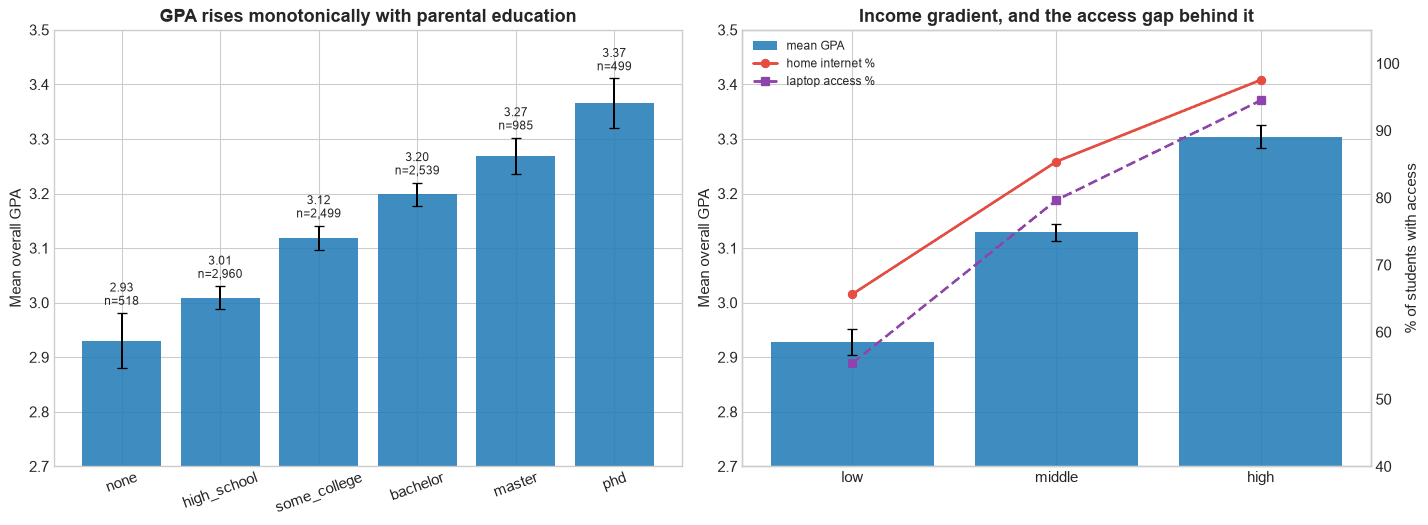

In [13]:
EDU_ORDER = ["none", "high_school", "some_college", "bachelor", "master", "phd"]
INC_ORDER = ["low", "middle", "high"]

edu = df.groupby("parental_education")["overall_gpa"]
edu_stats = pd.DataFrame(
    {"n": edu.size(), "mean_gpa": edu.mean(), "se": edu.std() / np.sqrt(edu.size())}
).reindex(EDU_ORDER)

inc = df.groupby("family_income")
inc_stats = pd.DataFrame(
    {
        "n": inc.size(),
        "mean_gpa": inc["overall_gpa"].mean(),
        "se": inc["overall_gpa"].std() / np.sqrt(inc.size()),
        "internet": inc["internet_access"].apply(lambda s: (s == "yes").mean()),
        "laptop": inc["has_laptop"].apply(lambda s: (s == "yes").mean()),
    }
).reindex(INC_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

ax = axes[0]
ax.bar(
    EDU_ORDER,
    edu_stats["mean_gpa"],
    yerr=1.96 * edu_stats["se"],
    color=BLUE,
    alpha=0.9,
    capsize=4,
)
ax.set_ylim(2.7, 3.5)
ax.set_ylabel("Mean overall GPA")
ax.set_title("GPA rises monotonically with parental education")
ax.tick_params(axis="x", rotation=20)
for i, (m, se, n) in enumerate(
    zip(edu_stats["mean_gpa"], edu_stats["se"], edu_stats["n"])
):
    ax.text(i, m + 1.96 * se + 0.015, f"{m:.2f}\nn={n:,}", ha="center", fontsize=9)

ax = axes[1]
ax.bar(
    INC_ORDER,
    inc_stats["mean_gpa"],
    yerr=1.96 * inc_stats["se"],
    color=BLUE,
    alpha=0.9,
    capsize=4,
    label="mean GPA",
)
ax.set_ylim(2.7, 3.5)
ax.set_ylabel("Mean overall GPA")
ax.set_title("Income gradient, and the access gap behind it")
ax2 = ax.twinx()
ax2.plot(
    INC_ORDER,
    inc_stats["internet"] * 100,
    "o-",
    color=ACCENT,
    linewidth=2,
    label="home internet %",
)
ax2.plot(
    INC_ORDER,
    inc_stats["laptop"] * 100,
    "s--",
    color="#8e44ad",
    linewidth=2,
    label="laptop access %",
)
ax2.set_ylim(40, 105)
ax2.set_ylabel("% of students with access")
ax2.grid(False)
lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, labels, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

print(edu_stats.round(3).to_string())
print()
print(inc_stats.round(3).to_string())
print()
print(
    f"none -> phd    : {edu_stats.loc['phd', 'mean_gpa'] - edu_stats.loc['none', 'mean_gpa']:+.3f} GPA"
)
print(
    f"low  -> high   : {inc_stats.loc['high', 'mean_gpa'] - inc_stats.loc['low', 'mean_gpa']:+.3f} GPA"
)

## 10. Where There Is No Structure <a id='nulls'></a>

A finding worth as much as the curves: several columns carry essentially
**nothing**. `gender`, `ethnicity`, `school_region`, `sports_participation` and
`extracurricular_activities` all move mean GPA by less than 0.05 points across
their entire range — inside noise for groups this size.

Two consequences.

- **Do not go feature-engineering in them.** The chart below is the map of where
  the signal is; anything at the bottom is a dead end.
- **They make clean negative controls.** A fairness audit run on this table
  *should* come back empty on `gender` and `ethnicity`. If your bias-detection
  pipeline reports disparate impact here, the pipeline is miscalibrated, not the
  data. That is a genuinely useful property for testing fairness tooling — but it
  also means this dataset cannot demonstrate real demographic bias, because none
  was written into it.


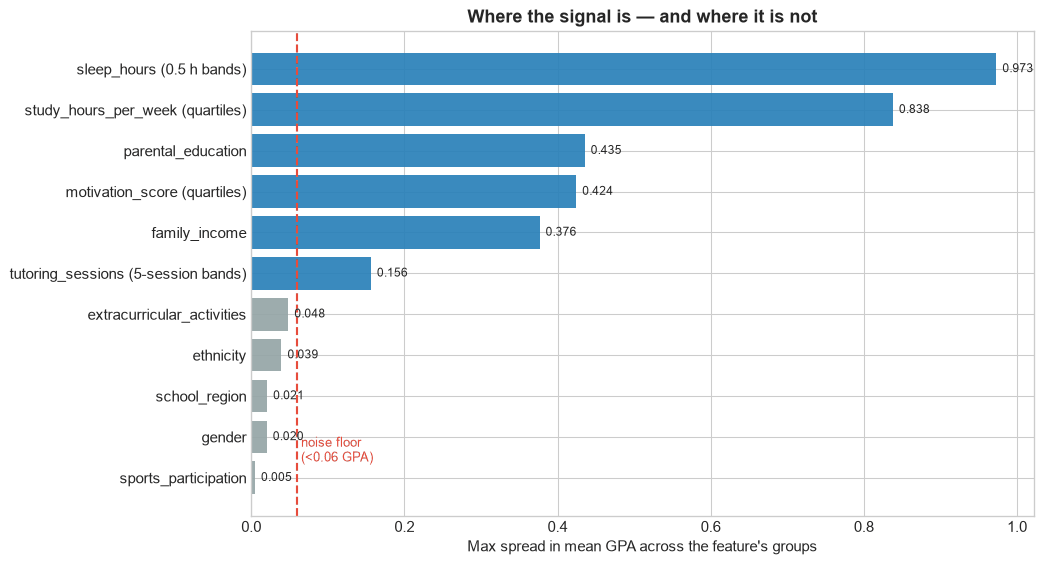

In [14]:
def spread(col, bins=None, right=True):
    key = pd.cut(df[col], bins, right=right) if bins is not None else df[col]
    means = df.groupby(key, observed=True)["overall_gpa"].mean()
    return means.max() - means.min()


effects = {
    # right=False to match the binning used in section 6
    "sleep_hours (0.5 h bands)": spread("sleep_hours", BIN_EDGES, right=False),
    "study_hours_per_week (quartiles)": spread(
        "study_hours_per_week",
        df["study_hours_per_week"].quantile([0, 0.25, 0.5, 0.75, 1]).values,
    ),
    "parental_education": spread("parental_education"),
    "family_income": spread("family_income"),
    "motivation_score (quartiles)": spread(
        "motivation_score",
        df["motivation_score"].quantile([0, 0.25, 0.5, 0.75, 1]).values,
    ),
    "tutoring_sessions (5-session bands)": spread(
        "tutoring_sessions", [-1, 0, 5, 10, 15, 20]
    ),
    "extracurricular_activities": spread("extracurricular_activities"),
    "ethnicity": spread("ethnicity"),
    "school_region": spread("school_region"),
    "gender": spread("gender"),
    "sports_participation": spread("sports_participation"),
}
eff = pd.Series(effects).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
colours = [GREY if v < 0.06 else BLUE for v in eff.values]
ax.barh(eff.index, eff.values, color=colours, alpha=0.92)
ax.axvline(0.06, color=ACCENT, linestyle="--", linewidth=1.6)
ax.text(0.065, 0.3, "noise floor\n(<0.06 GPA)", color=ACCENT, fontsize=10, va="bottom")
for i, v in enumerate(eff.values):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("Max spread in mean GPA across the feature's groups")
ax.set_title("Where the signal is — and where it is not")
plt.tight_layout()
plt.show()

## 11. Ceiling Effects & Other Caveats <a id='caveats'></a>

Three things that will bite a modeller who does not check them first.


In [15]:
print("1. Score ceiling — clipped at 100, so the top of every effect is compressed")
for c in SUBJECTS:
    print(f"   {c:<16} {(df[c] >= 100).mean() * 100:5.1f}% of rows sit exactly at 100")
print(
    f"   {'overall_gpa':<16} {(df['overall_gpa'] >= 4.0).mean() * 100:5.1f}% "
    "of rows sit exactly at 4.00"
)
print(
    "   -> every effect measured above is a LOWER bound on the generator's true effect."
)
print()

print("2. `passed` is severely imbalanced — do not report plain accuracy on it")
print(
    f"   pass rate: {df['passed'].mean() * 100:.1f}%  "
    f"(a constant 'everyone passes' classifier scores {df['passed'].mean() * 100:.1f}%)"
)
print("   -> use balanced accuracy, PR-AUC, or predict overall_gpa directly.")
print()

print("3. Thin tails on sleep_hours — the ends of the curve are the least certain")
tails = df["sleep_hours"].between(4, 5).sum(), df["sleep_hours"].between(9, 10).sum()
print(f"   4.0-5.0 h : {tails[0]:,} students ({tails[0] / len(df) * 100:.1f}%)")
print(f"   9.0-10.0 h: {tails[1]:,} students ({tails[1] / len(df) * 100:.1f}%)")
print(
    "   -> the 95% CIs in section 6 are wide there for a reason; do not over-read them."
)

1. Score ceiling — clipped at 100, so the top of every effect is compressed
   reading_score     11.7% of rows sit exactly at 100
   writing_score     10.8% of rows sit exactly at 100
   math_score        15.9% of rows sit exactly at 100
   science_score     14.1% of rows sit exactly at 100
   overall_gpa        4.5% of rows sit exactly at 4.00
   -> every effect measured above is a LOWER bound on the generator's true effect.

2. `passed` is severely imbalanced — do not report plain accuracy on it
   pass rate: 96.1%  (a constant 'everyone passes' classifier scores 96.1%)
   -> use balanced accuracy, PR-AUC, or predict overall_gpa directly.

3. Thin tails on sleep_hours — the ends of the curve are the least certain
   4.0-5.0 h : 549 students (5.5%)
   9.0-10.0 h: 495 students (5.0%)
   -> the 95% CIs in section 6 are wide there for a reason; do not over-read them.


## 12. Modeling Readiness <a id='modeling'></a>

The EDA translates into a concrete model spec: a linear baseline plus two
explicit quadratic terms should close most of the gap to a gradient-boosted
tree, because the non-linearity in this table is almost entirely those two
curves.


In [16]:
print("Modeling checklist")
print("=" * 62)
print(f"Target                : {TARGET_COL} (regression)")
print(f"Metric                : {PRIMARY_METRIC}, {VALIDATION_PLAN}")
print(f"Drop before fitting   : {', '.join(LEAKAGE_COLS)} + student_id")
print()
print("Engineered features earned by this EDA:")
print(f"  sleep_deviation_sq = (sleep_hours - {vertex:.2f}) ** 2      # section 6")
print("  tutoring_sq        = tutoring_sessions ** 2         # section 8")
print("  parental_edu_ord   = ordinal encode none..phd       # section 9")
print()
print("Skip (measured at or below the noise floor in section 10):")
print("  gender, ethnicity, school_region, sports_participation,")
print("  extracurricular_activities, age")
print()
print("Baseline stack:")
print("  Ridge on the above, then LightGBM; if the gap is small, the tree is")
print("  only rediscovering the two quadratics you already handed the linear model.")
print()
print("Risk checks:")
print("  - confirm no subject score leaked into the feature matrix")
print("  - inspect residuals at the sleep_hours tails and at the GPA=4.00 ceiling")

Modeling checklist
Target                : overall_gpa (regression)
Metric                : MAE (report RMSE alongside), 5-fold CV
Drop before fitting   : reading_score, writing_score, math_score, science_score + student_id

Engineered features earned by this EDA:
  sleep_deviation_sq = (sleep_hours - 7.44) ** 2      # section 6
  tutoring_sq        = tutoring_sessions ** 2         # section 8
  parental_edu_ord   = ordinal encode none..phd       # section 9

Skip (measured at or below the noise floor in section 10):
  gender, ethnicity, school_region, sports_participation,
  extracurricular_activities, age

Baseline stack:
  Ridge on the above, then LightGBM; if the gap is small, the tree is
  only rediscovering the two quadratics you already handed the linear model.

Risk checks:
  - confirm no subject score leaked into the feature matrix
  - inspect residuals at the sleep_hours tails and at the GPA=4.00 ceiling


## 13. Key Findings & Takeaways <a id='findings'></a>

Every number below is produced by a cell above — printed in a table or drawn on
a chart. Nothing here is asserted that the notebook does not also compute.

### Finding 1 — the sleep optimum is real, and it is asymmetric
A degree-2 fit peaks at **7.44 hours**, inside the 7–8 h window the dataset
advertises. Mean GPA at the peak band is **3.27**; at 4–5.5 h it is **2.67**
(−0.60) and at 9–10 h it is **2.93** (−0.34). Under-sleeping therefore costs
about **1.75× what over-sleeping costs** — the curve is not symmetric, so a
plain quadratic is a summary, not the exact generating shape. Adding one squared
term takes R² from **0.031 to 0.124**, a **4× increase**, and the squared term
survives at *t* ≈ −31 with study hours, attendance, motivation and stress all
controlled.

### Finding 2 — "diminishing returns" on tutoring was the wrong label
The marginal return per session does not flatten, it **reverses**. The fitted
curve peaks near **9.3 sessions**; the 6–10 band averages **3.19 GPA** against a
zero-session baseline of **3.03**. But the 16–20 band falls back to **3.05**,
and the 0-session vs 16–20 contrast is **+0.018 GPA, 95% CI [−0.039, +0.074]** —
statistically indistinguishable. Twenty sessions buys nothing over none. The
dataset description has been corrected to say so.

### Finding 3 — the socioeconomic gradient is monotonic and mediated by access
Mean GPA climbs at every step from `none` (**2.93**) to `phd` (**3.37**), a
**+0.44** span, and from low income (**2.93**) to high (**3.30**), **+0.38**.
Behind the income gap is a resource gap: home internet **66% → 98%**, laptop
access **55% → 95%**.

### Finding 4 — the demographic columns are deliberately empty
`gender`, `ethnicity`, `school_region`, `sports_participation` and
`extracurricular_activities` each move mean GPA by **< 0.05 points** end to end.
Useful as negative controls for fairness tooling; useless as features.

### Trade-offs, limitations, and caveats
- **Limitation — synthetic:** these are properties of a generator, not of real
  students. The value here is a known ground truth to test methods against.
- **Caveat — ceilings:** 11–16% of subject scores and 4.5% of GPAs sit exactly at
  the cap, so every effect above is a *lower bound* on what was generated.
- **Caveat — `stress_level`:** its bivariate slope on GPA is about **2×** its
  controlled slope, because it inherits variance from sleep and study hours. Do
  not read the heatmap row as an effect size.
- **Trade-off — binned means:** they make the shape legible but discard
  within-bin variance; the regression tables are the load-bearing evidence, the
  plots are the explanation.

### Next Steps
- Fit the Ridge-with-quadratics baseline from section 12 and check how much of
  the LightGBM gap it closes — the recommended test of whether the two curves
  are the whole story.
- Recover the optimum with a spline or GAM instead of a fixed quadratic; the
  asymmetry in Finding 1 suggests the true shape is not perfectly parabolic.
- Model the access-mediation path in section 9 explicitly (income → laptop /
  internet → GPA) rather than throwing all three into one flat feature matrix.
